In [1]:
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

In [2]:
ticker = yf.Ticker("NMDC.BO")

In [3]:
stock = ticker.history(start="2020-01-01")
stock

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2020-01-01 00:00:00+05:30,15.517305,15.517305,15.235717,15.379507,456797,0.0,0.0
2020-01-02 00:00:00+05:30,15.457392,15.762944,15.451401,15.721006,969035,0.0,0.0
2020-01-03 00:00:00+05:30,15.864796,15.864796,15.385498,15.481358,517307,0.0,0.0
2020-01-06 00:00:00+05:30,15.517306,15.571228,15.259684,15.493341,801983,0.0,0.0
2020-01-07 00:00:00+05:30,15.577219,15.679070,14.900210,15.343560,1810691,0.0,0.0
...,...,...,...,...,...,...,...
2026-03-30 00:00:00+05:30,76.599998,78.400002,76.099998,76.269997,1822714,0.0,0.0
2026-04-01 00:00:00+05:30,78.180000,79.489998,77.750000,78.150002,1247758,0.0,0.0
2026-04-02 00:00:00+05:30,78.099998,78.500000,75.650002,77.980003,818740,0.0,0.0


In [4]:
stock.index

DatetimeIndex(['2020-01-01 00:00:00+05:30', '2020-01-02 00:00:00+05:30',
               '2020-01-03 00:00:00+05:30', '2020-01-06 00:00:00+05:30',
               '2020-01-07 00:00:00+05:30', '2020-01-08 00:00:00+05:30',
               '2020-01-09 00:00:00+05:30', '2020-01-10 00:00:00+05:30',
               '2020-01-13 00:00:00+05:30', '2020-01-14 00:00:00+05:30',
               ...
               '2026-03-20 00:00:00+05:30', '2026-03-23 00:00:00+05:30',
               '2026-03-24 00:00:00+05:30', '2026-03-25 00:00:00+05:30',
               '2026-03-27 00:00:00+05:30', '2026-03-30 00:00:00+05:30',
               '2026-04-01 00:00:00+05:30', '2026-04-02 00:00:00+05:30',
               '2026-04-06 00:00:00+05:30', '2026-04-07 00:00:00+05:30'],
              dtype='datetime64[s, Asia/Kolkata]', name='Date', length=1550, freq=None)

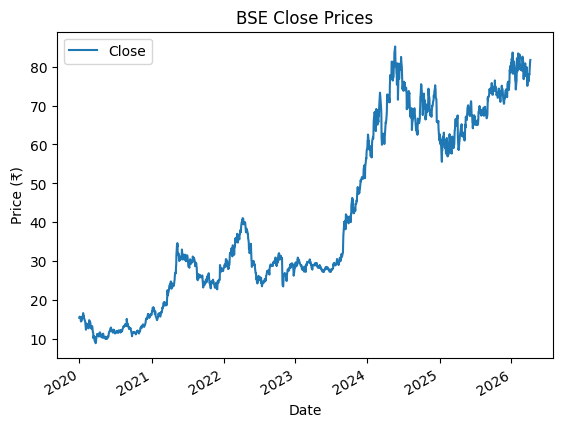

In [5]:
stock.plot.line(y="Close", use_index=True, title="BSE Close Prices")
plt.xlabel("Date")
plt.ylabel("Price (₹)")
plt.show()

In [6]:
del stock["Dividends"]
del stock["Stock Splits"]

In [7]:
stock["Tomorrow"] = stock["Close"].shift(-1)
stock

,Open,High,Low,Close,Volume,Tomorrow
Date,,,,,,
2020-01-01 00:00:00+05:30,15.517305,15.517305,15.235717,15.379507,456797,15.721006
2020-01-02 00:00:00+05:30,15.457392,15.762944,15.451401,15.721006,969035,15.481358
2020-01-03 00:00:00+05:30,15.864796,15.864796,15.385498,15.481358,517307,15.493341
2020-01-06 00:00:00+05:30,15.517306,15.571228,15.259684,15.493341,801983,15.343560
2020-01-07 00:00:00+05:30,15.577219,15.679070,14.900210,15.343560,1810691,14.600645
...,...,...,...,...,...,...
2026-03-30 00:00:00+05:30,76.599998,78.400002,76.099998,76.269997,1822714,78.150002
2026-04-01 00:00:00+05:30,78.180000,79.489998,77.750000,78.150002,1247758,77.980003
2026-04-02 00:00:00+05:30,78.099998,78.500000,75.650002,77.980003,818740,81.449997


In [8]:
stock["Target"] = (stock["Tomorrow"] > stock["Close"]).astype(int)
stock

,Open,High,Low,Close,Volume,Tomorrow,Target
Date,,,,,,,
2020-01-01 00:00:00+05:30,15.517305,15.517305,15.235717,15.379507,456797,15.721006,1
2020-01-02 00:00:00+05:30,15.457392,15.762944,15.451401,15.721006,969035,15.481358,0
2020-01-03 00:00:00+05:30,15.864796,15.864796,15.385498,15.481358,517307,15.493341,1
2020-01-06 00:00:00+05:30,15.517306,15.571228,15.259684,15.493341,801983,15.343560,0
2020-01-07 00:00:00+05:30,15.577219,15.679070,14.900210,15.343560,1810691,14.600645,0
...,...,...,...,...,...,...,...
2026-03-30 00:00:00+05:30,76.599998,78.400002,76.099998,76.269997,1822714,78.150002,1
2026-04-01 00:00:00+05:30,78.180000,79.489998,77.750000,78.150002,1247758,77.980003,0
2026-04-02 00:00:00+05:30,78.099998,78.500000,75.650002,77.980003,818740,81.449997,1


In [9]:
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(n_estimators = 300, min_samples_split = 50, random_state = 1)
train = stock.iloc[:-100]
test = stock.iloc[-100:]
predictors = ["Close","Volume","Open","High","Low"]
model.fit(train[predictors], train["Target"])

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",50
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metri

In [10]:
from sklearn.metrics import precision_score
preds = model.predict(test[predictors])

In [11]:
preds = pd.Series(preds, index = test.index)
precision_score(test["Target"], preds)

0.6122448979591837

<Axes: xlabel='Date'>

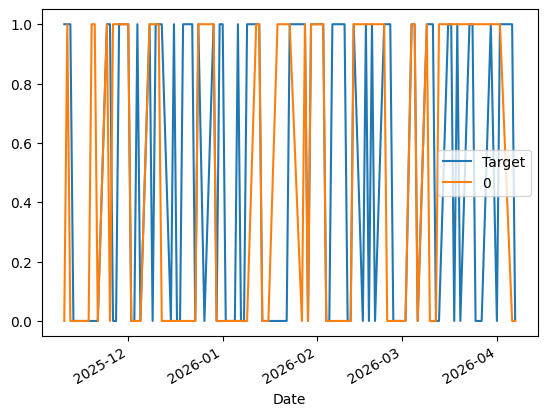

In [12]:
combined = pd.concat([test["Target"], preds], axis = 1)
combined.plot()

In [13]:
def predict(train, test, predictors, model):
    model.fit(train[predictors], train["Target"])
    preds = model.predict(test[predictors])
    preds = pd.Series(preds, index = test.index)
    combined = pd.concat([test["Target"], preds], axis = 1)
    return combined

In [14]:
def backtest(data, model, predictors, start = 500, step = 100):
    all_predictions = []
    for i in range(start, data.shape[0],step):
        train = data.iloc[0:i].copy()
        test = data.iloc[i:(i+step)].copy()
        predictions = predict(train, test, predictors, model)
        all_predictions.append(predictions)
    return pd.concat(all_predictions)

In [15]:
 predictions = backtest(stock, model, predictors)

In [16]:
precision_score(test["Target"], preds)

0.6122448979591837

In [17]:
from sklearn.metrics import precision_score
import pandas as pd
def predict(train, test, predictors, model, threshold=0.6):
    model.fit(train[predictors], train["Target"])
    pred_probs = model.predict_proba(test[predictors])[:,1]  
    pred_high_precision = (pred_probs >= threshold).astype(int)  
    prec = precision_score(test["Target"], pred_high_precision, zero_division=0)   
    combined = pd.DataFrame({
        "Target": test["Target"],
        "Predicted": pred_high_precision,
        "Probability": pred_probs
    }, index=test.index)
    return combined, prec

In [18]:
combined, precision = predict(train, test, predictors, model, threshold=0.6)
print("Precision on this test set:", precision)

Precision on this test set: 0.8181818181818182


<Axes: title={'center': 'Actual vs Predicted'}, xlabel='Date'>

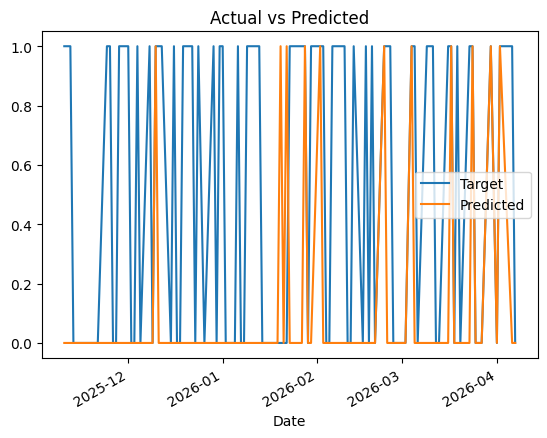

In [19]:
combined[["Target", "Predicted"]].plot(title="Actual vs Predicted")

In [20]:
from sklearn.ensemble import RandomForestRegressor
model = RandomForestRegressor(n_estimators=300, random_state=1)
model.fit(train[predictors], train["Close"])

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [21]:
X_new = pd.DataFrame(
    [[150.5, 2000000, 149.0, 151.0, 148.5]],
    columns=["Close","Volume","Open","High","Low"]
)
predicted_price = model.predict(X_new)
print("Next day price:", predicted_price[0])
today_close = stock["Close"].iloc[-1]  # actual most recent close
predicted_price = model.predict(X_new)[0]
direction = "UP" if predicted_price > today_close else "DOWN"
print("Today's close:", today_close)
print("Predicted next close:", predicted_price)
print("Direction:", direction)

Next day price: 84.23397247314453
Today's close: 81.75
Predicted next close: 84.23397247314453
Direction: UP
